Using Colab cache for faster access to the 'edges2shoes-dataset' dataset.
Dataset path: /kaggle/input/edges2shoes-dataset
Using device: cuda


CNN Epoch [4/5]: 100%|██████████| 12457/12457 [09:26<00:00, 21.99it/s, loss=0.186]


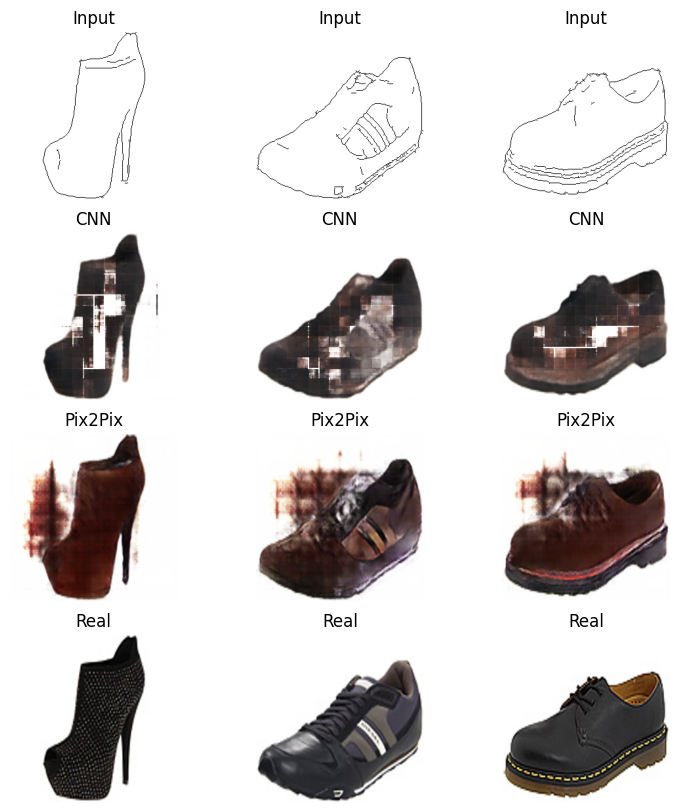

In [3]:
# =========================================================
# INSTALL + IMPORTS
# =========================================================
!pip install torch torchvision matplotlib pillow tqdm kagglehub -q

import os, glob
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
from tqdm import tqdm
import kagglehub

# =========================================================
# DOWNLOAD DATASET
# =========================================================
path = kagglehub.dataset_download("balraj98/edges2shoes-dataset")
print("Dataset path:", path)

# =========================================================
# DATASET
# =========================================================
class Edges2ShoesDataset(Dataset):
    def __init__(self, root_dir):
        self.files = sorted(glob.glob(root_dir + "/*.*"))
        self.transform = transforms.Compose([
            transforms.Resize((256,256)),
            transforms.ToTensor(),
            transforms.Normalize((0.5,), (0.5,))
        ])

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        img = Image.open(self.files[idx]).convert("RGB")
        w, h = img.size
        inp = img.crop((0, 0, w//2, h))
        tar = img.crop((w//2, 0, w, h))
        return self.transform(inp), self.transform(tar)

train_dataset = Edges2ShoesDataset(path + "/train")
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)

# =========================================================
# DEVICE
# =========================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# =========================================================
# PIX2PIX GENERATOR
# =========================================================
class UNetDown(nn.Module):
    def __init__(self, in_size, out_size, normalize=True):
        super().__init__()
        layers = [nn.Conv2d(in_size, out_size, 4, 2, 1)]
        if normalize:
            layers.append(nn.BatchNorm2d(out_size))
        layers.append(nn.LeakyReLU(0.2))
        self.model = nn.Sequential(*layers)
    def forward(self, x): return self.model(x)

class UNetUp(nn.Module):
    def __init__(self, in_size, out_size):
        super().__init__()
        self.model = nn.Sequential(
            nn.ConvTranspose2d(in_size, out_size, 4, 2, 1),
            nn.BatchNorm2d(out_size),
            nn.ReLU()
        )
    def forward(self, x, skip):
        x = self.model(x)
        return torch.cat((x, skip), 1)

class GeneratorUNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.down1 = UNetDown(3,64,False)
        self.down2 = UNetDown(64,128)
        self.down3 = UNetDown(128,256)
        self.down4 = UNetDown(256,512)
        self.down5 = UNetDown(512,512)

        self.up1 = UNetUp(512,512)
        self.up2 = UNetUp(1024,256)
        self.up3 = UNetUp(512,128)
        self.up4 = UNetUp(256,64)

        self.final = nn.Sequential(
            nn.ConvTranspose2d(128,3,4,2,1),
            nn.Tanh()
        )

    def forward(self,x):
        d1 = self.down1(x)
        d2 = self.down2(d1)
        d3 = self.down3(d2)
        d4 = self.down4(d3)
        d5 = self.down5(d4)

        u1 = self.up1(d5,d4)
        u2 = self.up2(u1,d3)
        u3 = self.up3(u2,d2)
        u4 = self.up4(u3,d1)

        return self.final(u4)

# =========================================================
# PIX2PIX DISCRIMINATOR (PATCHGAN)
# =========================================================
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        def block(in_c, out_c, norm=True):
            layers = [nn.Conv2d(in_c, out_c, 4, 2, 1)]
            if norm:
                layers.append(nn.BatchNorm2d(out_c))
            layers.append(nn.LeakyReLU(0.2))
            return layers

        self.model = nn.Sequential(
            *block(6,64,False),
            *block(64,128),
            *block(128,256),
            *block(256,512),
            nn.Conv2d(512,1,4,1,1)
        )

    def forward(self, x, y):
        inp = torch.cat((x,y),1)
        return self.model(inp)

# =========================================================
# INITIALIZE PIX2PIX
# =========================================================
G = GeneratorUNet().to(device)
D = Discriminator().to(device)

criterion_GAN = nn.BCEWithLogitsLoss()
criterion_L1 = nn.L1Loss()

opt_G = optim.Adam(G.parameters(), lr=0.0002, betas=(0.5,0.999))
opt_D = optim.Adam(D.parameters(), lr=0.0002, betas=(0.5,0.999))
lambda_L1 = 100

# =========================================================
# TRAIN PIX2PIX (FIXED LABEL SIZE)
# =========================================================
epochs = 5

for epoch in range(epochs):
    loop = tqdm(train_loader)

    for inp, real in loop:
        inp, real = inp.to(device), real.to(device)

        # ---- Train Generator ----
        opt_G.zero_grad()

        fake_img = G(inp)
        pred_fake = D(inp, fake_img)

        valid = torch.ones_like(pred_fake)   # FIXED
        loss_GAN = criterion_GAN(pred_fake, valid)
        loss_L1 = criterion_L1(fake_img, real)

        loss_G = loss_GAN + lambda_L1 * loss_L1
        loss_G.backward()
        opt_G.step()

        # ---- Train Discriminator ----
        opt_D.zero_grad()

        pred_real = D(inp, real)
        valid = torch.ones_like(pred_real)

        loss_real = criterion_GAN(pred_real, valid)

        pred_fake = D(inp, fake_img.detach())
        fake = torch.zeros_like(pred_fake)

        loss_fake = criterion_GAN(pred_fake, fake)

        loss_D = (loss_real + loss_fake)/2
        loss_D.backward()
        opt_D.step()

        loop.set_description(f"Pix2Pix Epoch [{epoch}/{epochs}]")
        loop.set_postfix(G_loss=loss_G.item(), D_loss=loss_D.item())

# =========================================================
# CNN BASELINE
# =========================================================
class EncoderDecoderCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(3,64,4,2,1), nn.ReLU(),
            nn.Conv2d(64,128,4,2,1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.Conv2d(128,256,4,2,1), nn.BatchNorm2d(256), nn.ReLU(),
            nn.Conv2d(256,512,4,2,1), nn.BatchNorm2d(512), nn.ReLU()
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(512,256,4,2,1), nn.BatchNorm2d(256), nn.ReLU(),
            nn.ConvTranspose2d(256,128,4,2,1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.ConvTranspose2d(128,64,4,2,1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.ConvTranspose2d(64,3,4,2,1), nn.Tanh()
        )
    def forward(self,x): return self.decoder(self.encoder(x))

cnn_model = EncoderDecoderCNN().to(device)
optimizer = optim.Adam(cnn_model.parameters(), lr=0.0002)
criterion = nn.L1Loss()

for epoch in range(5):
    loop = tqdm(train_loader)
    for inp, real in loop:
        inp, real = inp.to(device), real.to(device)
        optimizer.zero_grad()
        out = cnn_model(inp)
        loss = criterion(out, real)
        loss.backward()
        optimizer.step()
        loop.set_description(f"CNN Epoch [{epoch}/5]")
        loop.set_postfix(loss=loss.item())

# =========================================================
# VISUAL COMPARISON
# =========================================================
G.eval()
cnn_model.eval()

inp, real = next(iter(train_loader))
inp = inp.to(device)

with torch.no_grad():
    pix2pix_out = G(inp)
    cnn_out = cnn_model(inp)

inp = inp.cpu()*0.5 + 0.5
pix2pix_out = pix2pix_out.cpu()*0.5 + 0.5
cnn_out = cnn_out.cpu()*0.5 + 0.5
real = real*0.5 + 0.5

fig, axs = plt.subplots(4,3, figsize=(9,10))

for i in range(3):
    axs[0,i].imshow(inp[i].permute(1,2,0)); axs[0,i].set_title("Input")
    axs[1,i].imshow(cnn_out[i].permute(1,2,0)); axs[1,i].set_title("CNN")
    axs[2,i].imshow(pix2pix_out[i].permute(1,2,0)); axs[2,i].set_title("Pix2Pix")
    axs[3,i].imshow(real[i].permute(1,2,0)); axs[3,i].set_title("Real")

    for j in range(4):
        axs[j,i].axis("off")

plt.show()